In [68]:
!pip -q install rdkit torch-geometric tqdm scikit-learn requests matplotlib chembl_webresource_client

In [69]:
import torch

pt_version = torch.__version__.split('+')[0]

if torch.version.cuda is not None:
    device_version = 'cu' + torch.version.cuda.replace('.', '')
else:
    device_version = 'cpu'

print(f"PyTorch 버전: {pt_version}, 환경: {device_version}")

!pip install torch_geometric
!pip install pyg_lib torch_scatter torch_sparse -f https://data.pyg.org/whl/torch-{pt_version}+{device_version}.html

PyTorch 버전: 2.11.0, 환경: cpu
Looking in links: https://data.pyg.org/whl/torch-2.11.0+cpu.html


In [70]:
import os
import re
import time
import random
import requests
import numpy as np
import pandas as pd
import scipy.sparse as sp

from urllib.parse import quote
from tqdm.auto import tqdm
from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor, as_completed

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, roc_curve, precision_recall_curve
)

from rdkit import Chem, DataStructs
from rdkit.Chem import rdFingerprintGenerator

from torch_geometric.data import HeteroData
from torch_geometric.transforms import RandomLinkSplit
from torch_geometric.nn import HANConv
from torch_geometric.loader import LinkNeighborLoader

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"DEVICE: {DEVICE}")
print(f"SEED:   {SEED}")

DEVICE: cpu
SEED:   42


In [71]:
# -----------------------------
# Real Data Loading
# -----------------------------
import pandas as pd
import os

# gene_metabolite 제거 → drug/target/disease만 로드
required_files = [
    "real_drug_target_edges.csv",
    "real_target_disease_edges.csv"
]
for f in required_files:
    if not os.path.exists(f):
        raise FileNotFoundError(f"Missing file: {f}")

# --- Drug → Target (ChEMBL) ---
_dt_raw = pd.read_csv("real_drug_target_edges.csv")
drug_target_edges = (_dt_raw[["drug_id", "target_symbol", "confidence"]]
                     .rename(columns={"drug_id": "drug_name", "target_symbol": "target_id"})
                     .copy())
print(f"drug-target edges: {len(drug_target_edges)} rows  "
      f"({drug_target_edges['drug_name'].nunique()} drugs, "
      f"{drug_target_edges['target_id'].nunique()} targets)")

# --- Target → Disease (OpenTargets) ---
_td_raw = pd.read_csv("real_target_disease_edges.csv")
target_disease_edges = (_td_raw[["target_symbol", "disease_id", "disease_name", "association_score"]]
                        .rename(columns={"target_symbol": "target_id"})
                        .copy())
target_disease_edges["disease_id"]   = "ALOPECIA"
target_disease_edges["disease_name"] = "Alopecia"
print(f"target-disease edges: {len(target_disease_edges)} rows  "
      f"({target_disease_edges['target_id'].nunique()} targets)")

# --- Metabolite → pathway 파일에서 추출 (gene 없이) ---
PATHWAY_FILE = "All-pathways-of-S-cerevisiae-S288c_cleaned_compounds.txt"
if not os.path.exists(PATHWAY_FILE):
    raise FileNotFoundError(f"Missing file: {PATHWAY_FILE}")

# pathway 파일에서 compound 이름 전체 수집
pathway_compound_names = set()
pathway_records = []   # (pathway_name, compound_name) → co-pathway 엣지용
with open(PATHWAY_FILE, encoding="utf-8") as fh:
    next(fh)  # skip header
    for line in fh:
        parts = line.rstrip("\n").split("\t")
        if len(parts) < 2:
            continue
        pathway_name = parts[0].strip()
        compounds = [c.strip() for c in parts[1].split(" // ") if c.strip()]
        for c in compounds:
            pathway_compound_names.add(c)
            pathway_records.append({"pathway_name": pathway_name,
                                    "metabolite_name": c})

pathway_df = pd.DataFrame(pathway_records)
print(f"Pathway file: {pathway_df['pathway_name'].nunique()} pathways, "
      f"{len(pathway_compound_names)} unique compounds")

# metabolites_df = pathway 파일의 전체 compound
metabolites_df = pd.DataFrame({
    "metabolite_name": sorted(pathway_compound_names)
})

# -----------------------------
# Node tables
# -----------------------------
drugs_df = pd.DataFrame({
    "drug_name": sorted(drug_target_edges["drug_name"].astype(str).unique())
})

targets_df = pd.DataFrame({
    "target_id": sorted(
        set(drug_target_edges["target_id"].astype(str)) |
        set(target_disease_edges["target_id"].astype(str))
    )
})

diseases_df = pd.DataFrame({
    "disease_id":   ["ALOPECIA"],
    "disease_name": ["Alopecia"]
})

print(f"\n=== Node counts ===")
print(f"metabolites : {len(metabolites_df)}")
print(f"drugs       : {len(drugs_df)}")
print(f"targets     : {len(targets_df)}")
print(f"diseases    : {len(diseases_df)}")

display(metabolites_df.head(5))
display(drug_target_edges.head(5))
display(target_disease_edges.head(5))
display(pathway_df.head(5))

drug-target edges: 1286 rows  (257 drugs, 47 targets)
target-disease edges: 50 rows  (50 targets)
Pathway file: 344 pathways, 1133 unique compounds

=== Node counts ===
metabolites : 1133
drugs       : 257
targets     : 50
diseases    : 1


,metabolite_name
0,"(1,4-alpha-D-glucosyl)n-glucosyl glucogenin"
1,"(1R,2S)-homoisocitrate"
2,"(1S,2R)-1-C-(indol-3-yl)glycerol 3-phosphate"
3,(2E)-2-ethylidene-4-hydroxy-5-methyl-3(2H)-fur...
4,(2E)-dec-2-enoyl-CoA


,drug_name,target_id,confidence
0,CHEMBL2051761,IRF4,0.95
1,CHEMBL2442258,RSPO2,0.95
2,CHEMBL2374254,CIROZ,0.95
3,CHEMBL1916891,BMX,0.95
4,CHEMBL288441,BMX,0.95


,target_id,disease_id,disease_name,association_score
0,SHOC2,ALOPECIA,Alopecia,0.833247
1,PPP1CB,ALOPECIA,Alopecia,0.828199
2,HR,ALOPECIA,Alopecia,0.814037
3,LPAR6,ALOPECIA,Alopecia,0.813518
4,DSG4,ALOPECIA,Alopecia,0.809586


,pathway_name,metabolite_name
0,allantoin degradation to glyoxylate I,glyoxylate
1,allantoin degradation to glyoxylate I,H+
2,allantoin degradation to glyoxylate I,(S)-(+)-allantoin
3,allantoin degradation to glyoxylate I,urea
4,allantoin degradation to glyoxylate I,(S)-ureidoglycolate


In [72]:
# ── 1. Metabolite SMILES: pathway 파일에서 직접 읽기 ──────────────────
def load_pathway_compound_smiles(pathway_file: str) -> dict:
    """pathway TSV에서 {compound_name_lower: SMILES} 딕셔너리 반환"""
    comp_smiles = {}
    with open(pathway_file, encoding="utf-8") as fh:
        next(fh)  # skip header
        for line in fh:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 4:
                continue
            names_col  = [c.strip() for c in parts[1].split(" // ")]
            smiles_col = [s.strip() for s in parts[3].split(" // ")]
            for name, smi in zip(names_col, smiles_col):
                key = name.lower()
                if key and smi and key not in comp_smiles:
                    comp_smiles[key] = smi
    print(f"Pathway SMILES dict: {len(comp_smiles)} unique compounds")
    return comp_smiles

pathway_compound_smiles = load_pathway_compound_smiles(PATHWAY_FILE)

# metabolites_df에 SMILES 붙이기 (오프라인, API 불필요)
metabolites_df["smiles"] = metabolites_df["metabolite_name"].apply(
    lambda n: pathway_compound_smiles.get(n.lower())
)
print(f"Metabolites with SMILES: {metabolites_df['smiles'].notna().sum()} / {len(metabolites_df)}")

# ── 2. Drug SMILES: ChEMBL / PubChem API fetch ────────────────────────
# (기존 fetch 함수 그대로 유지)
def fetch_single_smiles(compound_name):
    if compound_name.upper().startswith("CHEMBL"):
        url = f"https://www.ebi.ac.uk/chembl/api/data/molecule/{compound_name.upper()}.json"
        try:
            r = requests.get(url, timeout=10)
            if r.status_code == 200:
                structs = r.json().get("molecule_structures") or {}
                smiles = structs.get("canonical_smiles") or structs.get("standard_smiles")
                if smiles:
                    return compound_name, smiles
        except Exception:
            pass
    safe_name = quote(compound_name)
    url = (f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/name/"
           f"{safe_name}/property/CanonicalSMILES,IsomericSMILES/JSON")
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            props = r.json().get("PropertyTable", {}).get("Properties", [])
            if props:
                smiles = (props[0].get("CanonicalSMILES") or
                          props[0].get("IsomericSMILES"))
                if smiles:
                    return compound_name, smiles
    except Exception:
        pass
    return compound_name, None

def fetch_smiles_concurrently(compound_list, max_workers=10):
    unique_names = list(set(compound_list))
    results = []
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        futures = {executor.submit(fetch_single_smiles, name): name
                   for name in unique_names}
        for future in tqdm(as_completed(futures), total=len(futures),
                           desc="Fetching SMILES"):
            name, smiles = future.result()
            results.append({"Name": name, "smiles": smiles})
            time.sleep(0.05)
    return pd.DataFrame(results)

print(f"\nTotal unique drugs to fetch: {len(drugs_df)}")
drug_smiles_df = fetch_smiles_concurrently(drugs_df["drug_name"].tolist(),
                                           max_workers=15)
drug_smiles_df["merge_name"] = drug_smiles_df["Name"].str.lower()
drugs_df["merge_name"] = drugs_df["drug_name"].str.lower()
drugs_df = (drugs_df
            .merge(drug_smiles_df[["merge_name", "smiles"]],
                   on="merge_name", how="left")
            .drop(columns=["merge_name"]))

# ── 3. SMILES 없는 행 제거 ─────────────────────────────────────────────
metabolites_df = metabolites_df.dropna(subset=["smiles"]).reset_index(drop=True)
drugs_df       = drugs_df.dropna(subset=["smiles"]).reset_index(drop=True)

print(f"\n=== After SMILES filter ===")
print(f"metabolites : {len(metabolites_df)}")
print(f"drugs       : {len(drugs_df)}")

display(metabolites_df.head(10))
display(drugs_df.head(10))

Pathway SMILES dict: 1085 unique compounds
Metabolites with SMILES: 1085 / 1133

Total unique drugs to fetch: 257


Fetching SMILES: 100%|██████████| 257/257 [00:21<00:00, 11.83it/s]


=== After SMILES filter ===
metabolites : 1085
drugs       : 257


,metabolite_name,smiles
0,"(1,4-alpha-D-glucosyl)n-glucosyl glucogenin",C(O)[C@H]3(O[C@H](O[C@H]2([C@H](O)[C@@H](O)[C@...
1,"(1R,2S)-homoisocitrate",C(CC(=O)[O-])[C@H](C(=O)[O-])[C@@H](O)C(=O)[O-]
2,"(1S,2R)-1-C-(indol-3-yl)glycerol 3-phosphate",C1(/NC2(/C=C\C=C/C(/C(/[C@@H]([C@@H](COP([O-])...
3,(2E)-2-ethylidene-4-hydroxy-5-methyl-3(2H)-fur...,C/C=C1(C(=O)C(/O)=C(C)\O1)
4,(2E)-dec-2-enoyl-CoA,CCCCCCC/C=C/C(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)...
5,(2E)-dodec-2-enoyl-CoA,CCCCCCCCC/C=C/C(SCCNC(=O)CCNC(=O)[C@H](O)C(C)(...
6,(2E)-icos-2-enoyl-CoA,CCCCCCCCCCCCCCCCC/C=C/C(=O)SCCNC(=O)CCNC([C@H]...
7,(2E)-tetradec-2-enoyl-CoA,CCCCCCCCCCC/C=C/C(SCCNC(=O)CCNC(=O)[C@H](O)C(C...
8,(2E)-undec-2-enoyl-CoA,CCCCCCCC/C=C/C(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C...
9,"(2E, 4E)-undeca-2,4-dienoyl-CoA",CCCCCC/C=C/C=C/C(=O)SCCNC(=O)CCNC(=O)[C@H](O)C...


,drug_name,smiles
0,CHEMBL1029,CCCCN1C[C@H](O)[C@@H](O)[C@H](O)[C@H]1CO
1,CHEMBL103667,Cc1ccc(-n2nc(C(C)(C)C)cc2NC(=O)Nc2ccc(OCCN3CCO...
2,CHEMBL104062,CC(=O)Nc1ccc(/C=C2\C(=O)Nc3ccc(C(=O)c4cccs4)cc...
3,CHEMBL104409,O=C1Nc2ccc(NC(=O)c3ccccc3)cc2/C1=C/c1ccc[nH]1
4,CHEMBL104640,CS(=O)(=O)c1ccc(/C=C2\C(=O)Nc3ccc(C(=O)c4cccs4...
5,CHEMBL104963,O=C1Nc2ccc(C(=O)c3cccs3)cc2/C1=C/c1ccc[nH]1
6,CHEMBL105255,CN(C)c1ccc(/C=C2\C(=O)Nc3ccc(C(=O)c4cccs4)cc32...
7,CHEMBL106571,O=C1Nc2cnc(-c3cccnc3)cc2/C1=C/c1ccc[nH]1
8,CHEMBL106944,O=C1Nc2ccc(C(=O)c3cccnc3)cc2/C1=C/c1ccc[nH]1
9,CHEMBL106961,O=C1Nc2ccc(C(=O)c3cccs3)cc2/C1=C/C(=O)c1ccc[nH]1


In [73]:
# SMILES 없는 행 제거 (이미 앞 셀에서 했으면 스킵 가능)
metabolites_df = metabolites_df.dropna(subset=["smiles"]).reset_index(drop=True)
drugs_df       = drugs_df.dropna(subset=["smiles"]).reset_index(drop=True)

# gene 없으므로 gene_metabolite_edges 제거
# drug-target edge에서 살아남은 drug만 유지
drug_target_edges = drug_target_edges[
    drug_target_edges["drug_name"].isin(drugs_df["drug_name"])
].reset_index(drop=True)

# pathway_df에서도 살아남은 metabolite만 유지
pathway_df = pathway_df[
    pathway_df["metabolite_name"].isin(metabolites_df["metabolite_name"])
].reset_index(drop=True)

print("=== After SMILES filtering ===")
print(f"metabolites      : {metabolites_df.shape}")
print(f"drugs            : {drugs_df.shape}")
print(f"drug-target edges: {drug_target_edges.shape}")
print(f"pathway records  : {pathway_df.shape}")

=== After SMILES filtering ===
metabolites      : (1085, 2)
drugs            : (257, 2)
drug-target edges: (1286, 3)
pathway records  : (4313, 2)


In [74]:
morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)

def smiles_to_mol(smiles):
    if pd.isna(smiles):
        return None
    mol = Chem.MolFromSmiles(str(smiles))
    return mol

def smiles_to_fp(smiles):
    mol = smiles_to_mol(smiles)
    if mol is None:
        return None
    return morgan_generator.GetFingerprint(mol)

metabolites_df["mol"] = metabolites_df["smiles"].apply(smiles_to_mol)
metabolites_df["fp"] = metabolites_df["smiles"].apply(smiles_to_fp)

drugs_df["mol"] = drugs_df["smiles"].apply(smiles_to_mol)
drugs_df["fp"] = drugs_df["smiles"].apply(smiles_to_fp)

metabolites_df = metabolites_df[metabolites_df["fp"].notna()].reset_index(drop=True)
drugs_df = drugs_df[drugs_df["fp"].notna()].reset_index(drop=True)

print("valid metabolites:", len(metabolites_df))
print("valid drugs:", len(drugs_df))

[22:19:52] SMILES Parse Error: syntax error while parsing: C(O)[C@H]3(O[C@H](O[C@H]2([C@H](O)[C@@H](O)[C@@H](OC1(\C=C/C(\C[C@@H](C([a
[22:19:52] SMILES Parse Error: check for mistakes around position 74:
[22:19:52] (\C=C/C(\C[C@@H](C([a
[22:19:52] ~~~~~~~~~~~~~~~~~~~~^
[22:19:52] SMILES Parse Error: extra open parentheses while parsing: C(O)[C@H]3(O[C@H](O[C@H]2([C@H](O)[C@@H](O)[C@@H](OC1(\C=C/C(\C[C@@H](C([a
[22:19:52] SMILES Parse Error: check for mistakes around position 11:
[22:19:52] C(O)[C@H]3(O[C@H](O[C@H]2([C@H](O)[C@@H](
[22:19:52] ~~~~~~~~~~^
[22:19:52] SMILES Parse Error: extra open parentheses while parsing: C(O)[C@H]3(O[C@H](O[C@H]2([C@H](O)[C@@H](O)[C@@H](OC1(\C=C/C(\C[C@@H](C([a
[22:19:52] SMILES Parse Error: check for mistakes around position 18:
[22:19:52] C(O)[C@H]3(O[C@H](O[C@H]2([C@H](O)[C@@H](
[22:19:52] ~~~~~~~~~~~~~~~~~^
[22:19:52] SMILES Parse Error: extra open parentheses while parsing: C(O)[C@H]3(O[C@H](O[C@H]2([C@H](O)[C@@H](O)[C@@H](OC1(\C=C/C(\C[C@@H](C([a

valid metabolites: 671
valid drugs: 257


In [75]:
TOP_K = 5

sim_rows = []

drug_names = drugs_df["drug_name"].tolist()
drug_fps = drugs_df["fp"].tolist()

for met_row in tqdm(metabolites_df.itertuples(index=False), total=len(metabolites_df)):
    met_name = met_row.metabolite_name
    met_fp = met_row.fp

    sims = DataStructs.BulkTanimotoSimilarity(met_fp, drug_fps)
    top_idx = np.argsort(sims)[::-1][:TOP_K]

    for j in top_idx:
        sim_rows.append({
            "metabolite_name": met_name,
            "drug_name": drug_names[j],
            "tanimoto": float(sims[j])
        })

metabolite_drug_edges = pd.DataFrame(sim_rows)

print("Metabolite-Drug similarity edges:", metabolite_drug_edges.shape)

display(
    metabolite_drug_edges
    .sort_values("tanimoto", ascending=False)
    .head(50)
)

100%|██████████| 671/671 [00:00<00:00, 17313.07it/s]

Metabolite-Drug similarity edges: (3355, 3)


,metabolite_name,drug_name,tanimoto
1045,4-coumarate,CHEMBL165,0.464286
1055,4-hydroxybenzaldehyde,CHEMBL165,0.458333
775,2-phenylethanol,CHEMBL5401203,0.428571
2980,phenylacetate,CHEMBL5401203,0.400000
960,3-phenyl-2-oxopropanoate,CHEMBL5401203,0.375000
1046,4-coumarate,CHEMBL362378,0.361702
2981,phenylacetate,CHEMBL271207,0.346154
2590,"ergosta-5,7,22,24(28)-tetraen-3beta-ol",CHEMBL2111947,0.338235
2374,beta-D-galactopyranose,CHEMBL2114210,0.333333
2155,alpha-D-galactopyranose,CHEMBL501355,0.333333


In [76]:
def make_mapping(values):
    values = sorted(pd.Series(values).dropna().astype(str).unique().tolist())
    id2idx = {v: i for i, v in enumerate(values)}
    idx2id = {i: v for v, i in id2idx.items()}
    return id2idx, idx2id

# gene 제거
met2idx,     idx2met     = make_mapping(metabolites_df["metabolite_name"])
drug2idx,    idx2drug    = make_mapping(drugs_df["drug_name"])
target2idx,  idx2target  = make_mapping(targets_df["target_id"])
disease2idx, idx2disease = make_mapping(diseases_df["disease_id"])

print("metabolite:", len(met2idx))
print("drug:",       len(drug2idx))
print("target:",     len(target2idx))
print("disease:",    len(disease2idx))

metabolite: 671
drug: 257
target: 50
disease: 1


In [77]:
def build_edge_index(df, src_col, dst_col, src_map, dst_map):
    src_list, dst_list = [], []
    for _, row in df.iterrows():
        s, d = str(row[src_col]), str(row[dst_col])
        if s in src_map and d in dst_map:
            src_list.append(src_map[s])
            dst_list.append(dst_map[d])
    if len(src_list) == 0:
        return torch.empty((2, 0), dtype=torch.long)
    return torch.tensor([src_list, dst_list], dtype=torch.long)


data = HeteroData()

# gene 노드 제거
data["metabolite"].num_nodes = len(met2idx)
data["drug"].num_nodes       = len(drug2idx)
data["target"].num_nodes     = len(target2idx)
data["disease"].num_nodes    = len(disease2idx)

# Metabolite -> Drug (Tanimoto)
md_edge = build_edge_index(
    metabolite_drug_edges, "metabolite_name", "drug_name",
    met2idx, drug2idx
)
data["metabolite", "similar_to",     "drug"      ].edge_index = md_edge
data["drug",       "rev_similar_to", "metabolite"].edge_index = md_edge.flip(0)

# Drug -> Target
dt_edge = build_edge_index(
    drug_target_edges, "drug_name", "target_id",
    drug2idx, target2idx
)
data["drug",   "inhibits",     "target"].edge_index = dt_edge
data["target", "rev_inhibits", "drug"  ].edge_index = dt_edge.flip(0)

# Target -> Disease
td_edge = build_edge_index(
    target_disease_edges, "target_id", "disease_id",
    target2idx, disease2idx
)
data["target",  "associated_with",     "disease"].edge_index = td_edge
data["disease", "rev_associated_with", "target" ].edge_index = td_edge.flip(0)

print(data)
print(data.metadata())

HeteroData(
  metabolite={ num_nodes=671 },
  drug={ num_nodes=257 },
  target={ num_nodes=50 },
  disease={ num_nodes=1 },
  (metabolite, similar_to, drug)={ edge_index=[2, 3355] },
  (drug, rev_similar_to, metabolite)={ edge_index=[2, 3355] },
  (drug, inhibits, target)={ edge_index=[2, 1286] },
  (target, rev_inhibits, drug)={ edge_index=[2, 1286] },
  (target, associated_with, disease)={ edge_index=[2, 50] },
  (disease, rev_associated_with, target)={ edge_index=[2, 50] }
)
(['metabolite', 'drug', 'target', 'disease'], [('metabolite', 'similar_to', 'drug'), ('drug', 'rev_similar_to', 'metabolite'), ('drug', 'inhibits', 'target'), ('target', 'rev_inhibits', 'drug'), ('target', 'associated_with', 'disease'), ('disease', 'rev_associated_with', 'target')])


In [78]:
import re
import scipy.sparse as sp
import numpy as np
import torch
from rdkit import DataStructs

# ── 1. Fingerprint → tensor 변환 함수 ──────────────────────────────
def fp_to_tensor(fp):
    arr = np.zeros((fp.GetNumBits(),), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp, arr)
    return torch.tensor(arr, dtype=torch.float)

# ── 2. RWPE 계산 함수들 ────────────────────────────────────────────
WALK_LEN = 20

# 반응마다 등장하는 cofactor (currency metabolite).
# 이걸 포함하면 H₂O·ATP가 super-hub가 되어 sterol 간 RWPE 구분이 무의미해짐.
CURRENCY_METABOLITES = {
    "h2o", "h+", "h", "water",
    "atp", "adp", "amp",
    "nad+", "nadh", "nadp+", "nadph",
    "coa", "acetyl-coa",
    "co2", "o2",
    "phosphate", "diphosphate", "pyrophosphate",
    "fad", "fadh2",
    "gtp", "gdp", "gmp",
    "ctp", "cdp", "ump", "udp", "utp",
    "a reduced thioredoxin", "an oxidized thioredoxin",
}

def build_pathway_graph(pathway_file):
    """pathway TSV → frequency-weighted co-reaction 그래프

    변경점 (binary 대비):
    1. Currency metabolite 제거 — H₂O, ATP 등이 만드는 spurious hub 방지
    2. Frequency weighting — 두 화합물이 N개 반응에서 같이 등장하면
       edge weight = N.  T = D_w⁻¹ W 로 row-normalize하면
       T[A,B] ∝ (A,B 공동 등장 횟수) / (A의 총 공동 등장 횟수).
       binary보다 대사적 coupling 강도를 더 잘 반영.
    """
    comp2idx  = {}
    edge_freq = {}   # (i, j) → 공동 등장 반응 수 (undirected, 양방향 저장)

    def _parse_side(side):
        out = []
        for tok in side.split("+"):
            tok = re.sub(r"^\d+\s+", "", tok.strip())
            if tok:
                out.append(tok.lower())
        return out

    with open(pathway_file, encoding="utf-8") as fh:
        next(fh)
        for line in fh:
            parts = line.rstrip("\n").split("\t")
            if len(parts) < 3:
                continue
            for rxn in parts[2].split(" // "):
                rxn = rxn.strip()
                m = re.search(r"<-+>|<-|->", rxn)
                if not m:
                    continue
                sep = m.group()
                left_str, right_str = rxn.split(sep, 1)
                lefts  = _parse_side(left_str)
                rights = _parse_side(right_str)

                # 모든 화합물을 comp2idx에 등록 (currency 포함)
                for c in lefts + rights:
                    if c not in comp2idx:
                        comp2idx[c] = len(comp2idx)

                # Currency를 제외한 substrate-product 쌍에 frequency +1
                for l in lefts:
                    if l in CURRENCY_METABOLITES:
                        continue
                    for r in rights:
                        if r in CURRENCY_METABOLITES or l == r:
                            continue
                        i, j = comp2idx[l], comp2idx[r]
                        edge_freq[(i, j)] = edge_freq.get((i, j), 0) + 1
                        edge_freq[(j, i)] = edge_freq.get((j, i), 0) + 1

    N = len(comp2idx)
    if N == 0 or not edge_freq:
        return comp2idx, sp.csr_matrix((N, N))

    rows = [k[0] for k in edge_freq]
    cols = [k[1] for k in edge_freq]
    vals = np.array([edge_freq[k] for k in edge_freq], dtype=np.float32)
    A = sp.csr_matrix((vals, (rows, cols)), shape=(N, N))
    print(f"Pathway graph: {N} compounds, {len(edge_freq)//2} edges "
          f"(frequency-weighted, currency filtered)")
    return comp2idx, A

def compute_rwpe_matrix(A, K):
    """RWPE[i,k] = (T^{k+1})[i,i],  T = D_w^{-1} A (frequency-weighted)"""
    N = A.shape[0]
    degree = np.array(A.sum(axis=1), dtype=np.float64).flatten()
    degree[degree == 0] = 1.0
    T = (sp.diags(1.0 / degree) @ A).astype(np.float32)
    rwpe = np.zeros((N, K), dtype=np.float32)
    T_k = T.copy()
    for k in range(K):
        rwpe[:, k] = np.array(T_k.diagonal()).flatten()
        if k < K - 1:
            T_k = T_k @ T
    return rwpe

def get_metabolite_rwpe(metabolite_names, comp2idx, rwpe_full, K):
    """metabolite 이름 리스트 → RWPE 벡터 (N_met, K)"""
    out = np.zeros((len(metabolite_names), K), dtype=np.float32)
    found = 0
    for i, name in enumerate(metabolite_names):
        key = name.lower()
        if key in comp2idx:
            out[i] = rwpe_full[comp2idx[key]]
            found += 1
    print(f"RWPE lookup: {found}/{len(metabolite_names)} matched")
    return out

# ── 3. RWPE 계산 ────────────────────────────────────────────────────
print("--- Building pathway reaction graph ---")
comp2idx, A_pathway = build_pathway_graph(PATHWAY_FILE)

print("--- Computing RWPE (K=20) ---")
if A_pathway.shape[0] > 0:
    rwpe_full = compute_rwpe_matrix(A_pathway, WALK_LEN)
else:
    print("[WARNING] Empty pathway graph, RWPE = zeros")
    rwpe_full = np.zeros((0, WALK_LEN), dtype=np.float32)

rwpe_met = get_metabolite_rwpe(
    metabolites_df["metabolite_name"].tolist(),
    comp2idx, rwpe_full, WALK_LEN
)

# ── 4. Node features 할당 ───────────────────────────────────────────
# Drug: Morgan FP (2048-d)
drug_x = torch.stack([fp_to_tensor(fp) for fp in drugs_df["fp"]])
data["drug"].x = drug_x
print(f"drug.x      : {data['drug'].x.shape}")

# Metabolite: concat(Morgan FP, RWPE)  →  (N_met, 2048 + 20)
met_fps  = torch.stack([fp_to_tensor(fp) for fp in metabolites_df["fp"]])
met_rwpe = torch.tensor(rwpe_met, dtype=torch.float32)
data["metabolite"].x = torch.cat([met_fps, met_rwpe], dim=-1)
print(f"metabolite.x: {data['metabolite'].x.shape}  "
      f"(Morgan 2048 + RWPE {WALK_LEN})")

# Target, Disease: constant 1-d feature
data["target"].x  = torch.ones((data["target"].num_nodes,  1), dtype=torch.float)
data["disease"].x = torch.ones((data["disease"].num_nodes, 1), dtype=torch.float)
print(f"target.x    : {data['target'].x.shape}")
print(f"disease.x   : {data['disease'].x.shape}")

--- Building pathway reaction graph ---
Pathway graph: 1147 compounds, 2032 edges (frequency-weighted, currency filtered)
--- Computing RWPE (K=20) ---
RWPE lookup: 594/671 matched
drug.x      : torch.Size([257, 2048])
metabolite.x: torch.Size([671, 2068])  (Morgan 2048 + RWPE 20)
target.x    : torch.Size([50, 1])
disease.x   : torch.Size([1, 1])


In [79]:
TASK_EDGE_TYPES = [
    ("metabolite", "similar_to", "drug"),
    ("drug", "inhibits", "target"),
]

REV_EDGE_TYPES = [
    ("drug", "rev_similar_to", "metabolite"),
    ("target", "rev_inhibits", "drug"),
]

transform = RandomLinkSplit(
    num_val=0.2,
    num_test=0.2,
    is_undirected=False,
    add_negative_train_samples=True,  # 여기서만 negative sampling
    neg_sampling_ratio=1.0,
    edge_types=TASK_EDGE_TYPES,
    rev_edge_types=REV_EDGE_TYPES,
)

train_data, val_data, test_data = transform(data)


# -----------------------------
# Minibatch DataLoaders (LinkNeighborLoader)
# -----------------------------
from torch_geometric.loader import LinkNeighborLoader

train_loader = []
for edge_type in TASK_EDGE_TYPES:
    if edge_type in train_data.edge_types and hasattr(train_data[edge_type], 'edge_label_index'):
        train_loader.append(
            LinkNeighborLoader(
                train_data,
                num_neighbors=[10, 5],
                edge_label_index=(edge_type, train_data[edge_type].edge_label_index),
                edge_label=train_data[edge_type].edge_label,
                batch_size=128,
                shuffle=True,
                # neg_sampling_ratio 제거: RandomLinkSplit에서 이미 처리
            )
        )

val_loader = []
for edge_type in TASK_EDGE_TYPES:
    if edge_type in val_data.edge_types and hasattr(val_data[edge_type], 'edge_label_index'):
        val_loader.append(
            LinkNeighborLoader(
                val_data,
                num_neighbors=[10, 5],
                edge_label_index=(edge_type, val_data[edge_type].edge_label_index),
                edge_label=val_data[edge_type].edge_label,
                batch_size=128,
                shuffle=False,
            )
        )

test_loader = []
for edge_type in TASK_EDGE_TYPES:
    if edge_type in test_data.edge_types and hasattr(test_data[edge_type], 'edge_label_index'):
        test_loader.append(
            LinkNeighborLoader(
                test_data,
                num_neighbors=[10, 5],
                edge_label_index=(edge_type, test_data[edge_type].edge_label_index),
                edge_label=test_data[edge_type].edge_label,
                batch_size=128,
                shuffle=False,
            )
        )

print("Train loaders:", len(train_loader))
print("Val loaders:  ", len(val_loader))
print("Test loaders: ", len(test_loader))

for i, edge_type in enumerate(TASK_EDGE_TYPES):
    if edge_type in train_data.edge_types:
        pos = (train_data[edge_type].edge_label == 1).sum().item()
        neg = (train_data[edge_type].edge_label == 0).sum().item()
        print(f"{edge_type} → pos: {pos}, neg: {neg}")

Train loaders: 2
Val loaders:   2
Test loaders:  2
('metabolite', 'similar_to', 'drug') → pos: 2013, neg: 2013
('drug', 'inhibits', 'target') → pos: 772, neg: 772


In [80]:
class InductiveHANLinkPredictor(nn.Module):
    def __init__(self, metadata, in_channels_dict,
                 hidden_channels=256, out_channels=256,  # 64 → 256
                 heads=4, dropout=0.1):
        super().__init__()
        self.node_proj = nn.ModuleDict({
            node_type: nn.Linear(in_channels, hidden_channels)
            for node_type, in_channels in in_channels_dict.items()
        })
        self.conv1 = HANConv(hidden_channels, hidden_channels,
                             metadata=metadata, heads=heads, dropout=dropout)
        self.conv2 = HANConv(hidden_channels, out_channels,
                             metadata=metadata, heads=heads, dropout=dropout)

    def forward(self, data):
        # 1. 초기 Feature Projection → 256차원
        x_dict_proj = {
            node_type: self.node_proj[node_type](x)
            for node_type, x in data.x_dict.items()
        }

        # 2. First HANConv + residual
        out1 = self.conv1(x_dict_proj, data.edge_index_dict)
        x_dict = {}
        for k in x_dict_proj:
            conv_out = out1.get(k)
            x_dict[k] = F.elu(conv_out + x_dict_proj[k]) if conv_out is not None \
                         else F.elu(x_dict_proj[k])

        # 3. Second HANConv + residual (activation 없음)
        out2 = self.conv2(x_dict, data.edge_index_dict)
        final_dict = {}
        for k in x_dict:
            conv_out = out2.get(k)
            final_dict[k] = conv_out + x_dict[k] if conv_out is not None \
                            else x_dict[k]

        return final_dict

    def decode(self, z_dict, edge_label_index, src_type, dst_type):
        src_z = z_dict[src_type][edge_label_index[0]]
        dst_z = z_dict[dst_type][edge_label_index[1]]
        return (src_z * dst_z).sum(dim=-1)

In [81]:
in_channels_dict = {
    node_type: data[node_type].x.size(-1)
    for node_type in data.node_types
}

print("in_channels_dict:", in_channels_dict)
# 예상: {'metabolite': 2068, 'drug': 2048, 'target': 1, 'disease': 1}

model = InductiveHANLinkPredictor(
    metadata=data.metadata(),
    in_channels_dict=in_channels_dict,
    hidden_channels=256,  # 64 → 256
    out_channels=256,     # 64 → 256
    heads=4,
    dropout=0.1,
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-4,
)

print(model)

in_channels_dict: {'metabolite': 2068, 'drug': 2048, 'target': 1, 'disease': 1}
InductiveHANLinkPredictor(
  (node_proj): ModuleDict(
    (metabolite): Linear(in_features=2068, out_features=256, bias=True)
    (drug): Linear(in_features=2048, out_features=256, bias=True)
    (target): Linear(in_features=1, out_features=256, bias=True)
    (disease): Linear(in_features=1, out_features=256, bias=True)
  )
  (conv1): HANConv(256, heads=4)
  (conv2): HANConv(256, heads=4)
)


In [82]:
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score
from collections import defaultdict
import numpy as np
import torch

@torch.no_grad()
def evaluate_auc_ap(model, loaders, edge_types, device):
    model.eval()

    y_true_dict = defaultdict(list)
    y_prob_dict = defaultdict(list)

    for loader, edge_type in zip(loaders, edge_types):
        for batch in loader:
            batch = batch.to(device)
            z_dict = model(batch)

            if edge_type not in batch.edge_types or not hasattr(batch[edge_type], 'edge_label_index'):
                continue

            src_type, rel_type, dst_type = edge_type
            edge_label_index = batch[edge_type].edge_label_index
            edge_label = batch[edge_type].edge_label.float()

            logits = model.decode(z_dict, edge_label_index, src_type, dst_type)
            probs = torch.sigmoid(logits).cpu().numpy()
            labels = edge_label.cpu().numpy()

            y_true_dict[edge_type].extend(labels)
            y_prob_dict[edge_type].extend(probs)

    results = {}
    for edge_type in edge_types:
        if edge_type not in y_true_dict or len(y_true_dict[edge_type]) == 0:
            continue

        y_true = np.array(y_true_dict[edge_type])
        probs = np.array(y_prob_dict[edge_type])

        if len(np.unique(y_true)) < 2:
            auc, ap, f1 = np.nan, np.nan, np.nan
        else:
            auc = roc_auc_score(y_true, probs)
            ap = average_precision_score(y_true, probs)
            preds = (probs > 0.5).astype(int)
            f1 = f1_score(y_true, preds, zero_division=0)

        results[edge_type] = {"AUC": auc, "AP": ap, "F1": f1}

    return results

def compute_loss(model, batch, task_edge_types):
    z_dict = model(batch)
    losses = []

    for edge_type in task_edge_types:
        if edge_type not in batch.edge_types or not hasattr(batch[edge_type], 'edge_label_index'):
            continue

        src_type, rel_type, dst_type = edge_type
        edge_label_index = batch[edge_type].edge_label_index
        edge_label = batch[edge_type].edge_label.float()

        logits = model.decode(z_dict, edge_label_index, src_type, dst_type)
        loss = torch.nn.functional.binary_cross_entropy_with_logits(logits, edge_label)
        losses.append(loss)

    if not losses:
        # If batch doesn't contain any target edges, return 0 with requires_grad
        return torch.tensor(0.0, device=z_dict[list(z_dict.keys())[0]].device, requires_grad=True)

    return sum(losses) / len(losses)

Epoch 005 | Loss 0.0752 | Val mean AP 0.9339 | Val mean F1 0.6308
  ('metabolite', 'similar_to', 'drug'): AUC=0.9397, AP=0.9413, F1=0.8653
  ('drug', 'inhibits', 'target'): AUC=0.9472, AP=0.9265, F1=0.3963
Epoch 010 | Loss 0.0253 | Val mean AP 0.9554 | Val mean F1 0.8979
  ('metabolite', 'similar_to', 'drug'): AUC=0.9316, AP=0.9271, F1=0.8574
  ('drug', 'inhibits', 'target'): AUC=0.9800, AP=0.9838, F1=0.9384
Epoch 015 | Loss 0.0091 | Val mean AP 0.9625 | Val mean F1 0.9098
  ('metabolite', 'similar_to', 'drug'): AUC=0.9426, AP=0.9372, F1=0.8724
  ('drug', 'inhibits', 'target'): AUC=0.9846, AP=0.9878, F1=0.9472
Epoch 020 | Loss 0.0027 | Val mean AP 0.9614 | Val mean F1 0.9040
  ('metabolite', 'similar_to', 'drug'): AUC=0.9363, AP=0.9338, F1=0.8560
  ('drug', 'inhibits', 'target'): AUC=0.9864, AP=0.9890, F1=0.9520
Epoch 025 | Loss 0.0401 | Val mean AP 0.9546 | Val mean F1 0.9004
  ('metabolite', 'similar_to', 'drug'): AUC=0.9299, AP=0.9235, F1=0.8666
  ('drug', 'inhibits', 'target'): AUC

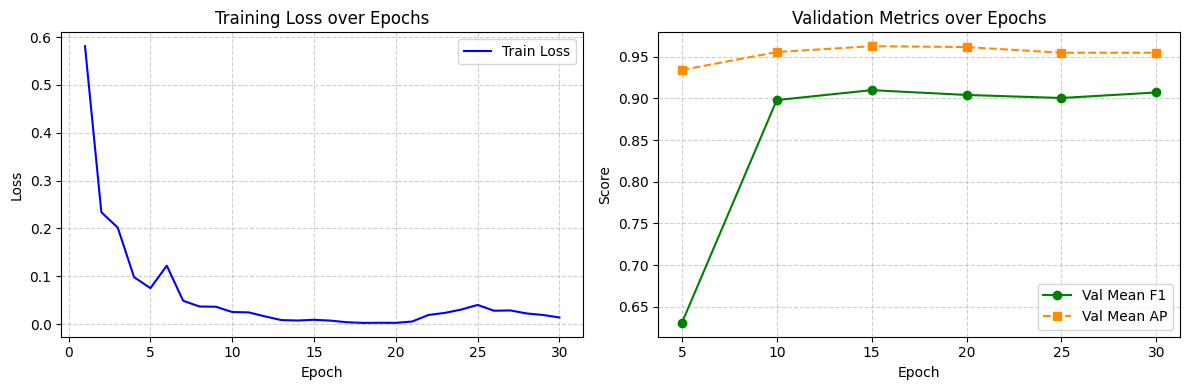

In [83]:
import matplotlib.pyplot as plt
import numpy as np

EPOCHS = 30 # Reduced for minibatch speed

best_val_ap = -1
best_state = None

history = {
    "train_loss": [],
    "val_mean_ap": [],
    "val_mean_f1": []
}

valid_train_edge_types = [et for et in TASK_EDGE_TYPES if et in train_data.edge_types and hasattr(train_data[et], 'edge_label_index')]
valid_val_edge_types = [et for et in TASK_EDGE_TYPES if et in val_data.edge_types and hasattr(val_data[et], 'edge_label_index')]

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss = 0
    num_batches = 0

    iterators = [(etype, iter(loader)) for etype, loader in zip(valid_train_edge_types, train_loader)]
    active_iterators = iterators[:]

    while active_iterators:
        etype, it = active_iterators.pop(0)
        try:
            batch = next(it)
            active_iterators.append((etype, it))
        except StopIteration:
            continue

        batch = batch.to(DEVICE)
        optimizer.zero_grad()
        loss = compute_loss(model, batch, [etype])

        if loss.item() > 0:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
            num_batches += 1

    avg_loss = total_loss / max(1, num_batches)
    history["train_loss"].append(avg_loss)

    if epoch % 5 == 0:
        val_result = evaluate_auc_ap(model, val_loader, valid_val_edge_types, DEVICE)
        if not val_result: continue

        mean_val_ap = np.nanmean([v["AP"] for v in val_result.values()])
        mean_val_f1 = np.nanmean([v["F1"] for v in val_result.values()])

        if mean_val_ap > best_val_ap:
            best_val_ap = mean_val_ap
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(f"Epoch {epoch:03d} | Loss {avg_loss:.4f} | Val mean AP {mean_val_ap:.4f} | Val mean F1 {mean_val_f1:.4f}")
        for etype, metrics in val_result.items():
            print(f"  {etype}: AUC={metrics['AUC']:.4f}, AP={metrics['AP']:.4f}, F1={metrics['F1']:.4f}")

        history["val_mean_ap"].append((epoch, mean_val_ap))
        history["val_mean_f1"].append((epoch, mean_val_f1))

if best_state is not None:
    model.load_state_dict(best_state)

print("Training finished.")

# -------- Plotting Training Progress --------
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), history["train_loss"], label="Train Loss", color='blue')
plt.title("Training Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.subplot(1, 2, 2)
if history["val_mean_ap"]:
    val_epochs, val_aps = zip(*history["val_mean_ap"])
    val_epochs, val_f1s = zip(*history["val_mean_f1"])

    plt.plot(val_epochs, val_f1s, label="Val Mean F1", marker='o', color='green', linestyle='-')
    plt.plot(val_epochs, val_aps, label="Val Mean AP", marker='s', color='darkorange', linestyle='--')
    plt.title("Validation Metrics over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

plt.tight_layout()
plt.show()

In [84]:
@torch.no_grad()
def recall_at_k(model, batch_data, edge_type, k=3):
    model.eval()

    # 중요: test_data도 model과 같은 device로 이동
    batch_data = batch_data.to(DEVICE)

    # edge type이 존재하는지 확인
    if edge_type not in batch_data.edge_types:
        print(f"[Warning] Edge type not found: {edge_type}")
        return np.nan

    src_type, rel_type, dst_type = edge_type

    # edge_label_index / edge_label이 있는지 확인
    if not hasattr(batch_data[edge_type], "edge_label_index"):
        print(f"[Warning] edge_label_index not found for {edge_type}")
        return np.nan

    if not hasattr(batch_data[edge_type], "edge_label"):
        print(f"[Warning] edge_label not found for {edge_type}")
        return np.nan

    z_dict = model(batch_data)

    edge_label_index = batch_data[edge_type].edge_label_index
    edge_label = batch_data[edge_type].edge_label

    # positive edge만 사용
    pos_mask = edge_label > 0.5
    pos_edge_index = edge_label_index[:, pos_mask]

    if pos_edge_index.size(1) == 0:
        print(f"[Warning] No positive edges for {edge_type}")
        return np.nan

    dst_all = z_dict[dst_type]
    hits = 0

    for i in range(pos_edge_index.size(1)):
        src_idx = pos_edge_index[0, i].long()
        true_dst_idx = pos_edge_index[1, i].long()

        src_vec = z_dict[src_type][src_idx]

        # dot product score: 모든 dst 후보와 src 하나의 유사도 계산
        scores = torch.matmul(dst_all, src_vec)

        topk = torch.topk(
            scores,
            k=min(k, dst_all.size(0))
        ).indices

        if (topk == true_dst_idx).any():
            hits += 1

    return hits / pos_edge_index.size(1)

In [85]:
@torch.no_grad()
def rank_metabolites_for_disease(
    model,
    full_data,
    disease_id="ALOPECIA",
    top_k=100,
):
    model.eval()
    full_data = full_data.to(DEVICE)
    z_dict = model(full_data)

    if disease_id not in disease2idx:
        raise ValueError(f"{disease_id} not found.")

    disease_idx = disease2idx[disease_id]
    disease_vec = z_dict["disease"][disease_idx]
    metabolite_mat = z_dict["metabolite"]

    # sigmoid 제거, L2 normalize 후 cosine similarity로 ranking
    metabolite_mat = F.normalize(metabolite_mat, p=2, dim=-1)
    disease_vec    = F.normalize(disease_vec,    p=2, dim=-1)

    scores = torch.matmul(metabolite_mat, disease_vec)  # cosine similarity [-1, 1]

    top = torch.topk(scores, k=min(top_k, scores.size(0)))

    rows = []
    for rank, (idx, score) in enumerate(
        zip(top.indices.cpu().tolist(), top.values.cpu().tolist()),
        start=1
    ):
        rows.append({
            "rank": rank,
            "metabolite_name": idx2met[idx],
            "disease_id": disease_id,
            "metabolite_gnn_score": round(float(score), 4),
        })

    return pd.DataFrame(rows)


metabolite_rank_df = rank_metabolites_for_disease(
    model,
    data,
    disease_id="ALOPECIA",
    top_k=100,
)

display(metabolite_rank_df)

,rank,metabolite_name,disease_id,metabolite_gnn_score
0,1,5-(2-hydroxyethyl)-4-methylthiazole,ALOPECIA,0.1636
1,2,H+,ALOPECIA,0.1587
2,3,D-threo-isocitrate,ALOPECIA,0.1582
3,4,a 1-phosphatidyl-1D-myo-inositol 5-phosphate,ALOPECIA,0.1577
4,5,"1-phosphatidyl-1D-myo-inositol 3,4,5-trisphosp...",ALOPECIA,0.1577
...,...,...,...,...
95,96,citrate,ALOPECIA,0.0913
96,97,alpha-D-glucopyranose,ALOPECIA,0.0913
97,98,choline,ALOPECIA,0.0910
98,99,beta-D-glucopyranose,ALOPECIA,0.0907


In [86]:
def build_path_explanation():
    rows = []

    for met in metabolites_df["metabolite_name"].unique():

        sim_hits = metabolite_drug_edges[
            metabolite_drug_edges["metabolite_name"] == met
        ]

        for _, sim in sim_hits.iterrows():
            drug = sim["drug_name"]
            tanimoto = sim["tanimoto"]

            dt_hits = drug_target_edges[
                drug_target_edges["drug_name"] == drug
            ]

            for _, dt in dt_hits.iterrows():
                target = dt["target_id"]
                dt_conf = dt["confidence"]

                td_hits = target_disease_edges[
                    target_disease_edges["target_id"] == target
                ]

                for _, td in td_hits.iterrows():
                    disease = td["disease_id"]
                    disease_score = td["association_score"]

                    path_score = tanimoto * dt_conf * disease_score

                    rows.append({
                        "metabolite": met,
                        "similar_drug": drug,
                        "target": target,
                        "disease": disease,
                        "tanimoto": tanimoto,
                        "drug_target_confidence": dt_conf,
                        "target_disease_score": disease_score,
                        "path_score": path_score,
                    })

    return pd.DataFrame(rows)


path_df = build_path_explanation()

display(
    path_df.sort_values("path_score", ascending=False).head(30)
)

,metabolite,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
30371,beta-D-glucopyranose,CHEMBL501355,SHOC2,ALOPECIA,0.333333,0.95,0.833247,0.263862
30191,beta-D-galactopyranose,CHEMBL501355,SHOC2,ALOPECIA,0.333333,0.95,0.833247,0.263862
27411,alpha-D-glucopyranose,CHEMBL501355,SHOC2,ALOPECIA,0.333333,0.95,0.833247,0.263862
27051,alpha-D-galactopyranose,CHEMBL501355,SHOC2,ALOPECIA,0.333333,0.95,0.833247,0.263862
30551,beta-D-mannopyranose,CHEMBL501355,SHOC2,ALOPECIA,0.333333,0.95,0.833247,0.263862
30364,beta-D-glucopyranose,CHEMBL501355,PPP1CB,ALOPECIA,0.333333,0.95,0.828199,0.262263
30184,beta-D-galactopyranose,CHEMBL501355,PPP1CB,ALOPECIA,0.333333,0.95,0.828199,0.262263
27044,alpha-D-galactopyranose,CHEMBL501355,PPP1CB,ALOPECIA,0.333333,0.95,0.828199,0.262263
27404,alpha-D-glucopyranose,CHEMBL501355,PPP1CB,ALOPECIA,0.333333,0.95,0.828199,0.262263
30544,beta-D-mannopyranose,CHEMBL501355,PPP1CB,ALOPECIA,0.333333,0.95,0.828199,0.262263


In [87]:
# -----------------------------
# Metabolite-level final ranking
# GNN score + path score
# -----------------------------

if "metabolite_name" not in path_df.columns and "metabolite" in path_df.columns:
    path_df = path_df.rename(columns={"metabolite": "metabolite_name"})

alopecia_path_df = path_df[path_df["disease"] == "ALOPECIA"].copy()

# metabolite별 최고 path score (gene 관련 집계 제거)
metabolite_path_score = (
    alopecia_path_df
    .groupby("metabolite_name")
    .agg(
        path_score=("path_score", "max"),
        num_paths=("path_score", "count"),
    )
    .reset_index()
)

# 0~1 scaling
if len(metabolite_path_score) > 0:
    max_path = metabolite_path_score["path_score"].max()
    if max_path > 0:
        metabolite_path_score["path_score_scaled"] = (
            metabolite_path_score["path_score"] / max_path
        )
    else:
        metabolite_path_score["path_score_scaled"] = 0.0
else:
    metabolite_path_score["path_score_scaled"] = 0.0

# metabolite_rank_df와 merge
final_metabolite_rank_df = metabolite_rank_df.merge(
    metabolite_path_score[
        ["metabolite_name", "path_score", "path_score_scaled", "num_paths"]
    ],
    on="metabolite_name",
    how="left"
)

# path 없는 metabolite는 0점 처리
final_metabolite_rank_df["path_score"] = (
    final_metabolite_rank_df["path_score"].fillna(0.0)
)
final_metabolite_rank_df["path_score_scaled"] = (
    final_metabolite_rank_df["path_score_scaled"].fillna(0.0)
)
final_metabolite_rank_df["num_paths"] = (
    final_metabolite_rank_df["num_paths"].fillna(0).astype(int)
)

# 최종 score
final_metabolite_rank_df["final_score"] = (
    0.5 * final_metabolite_rank_df["metabolite_gnn_score"]
    + 0.5 * final_metabolite_rank_df["path_score_scaled"]
)

final_metabolite_rank_df = final_metabolite_rank_df.sort_values(
    "final_score", ascending=False
).reset_index(drop=True)

final_metabolite_rank_df["final_rank"] = np.arange(
    1, len(final_metabolite_rank_df) + 1
)

display(final_metabolite_rank_df[[
    "final_rank",
    "metabolite_name",
    "metabolite_gnn_score",
    "path_score",
    "path_score_scaled",
    "num_paths",
    "final_score",
]])

,final_rank,metabolite_name,metabolite_gnn_score,path_score,path_score_scaled,num_paths,final_score
0,1,alpha-D-glucopyranose,0.0913,0.263862,1.000000,180,0.545650
1,2,beta-D-glucopyranose,0.0907,0.263862,1.000000,180,0.545350
2,3,"alpha,alpha-trehalose",0.1052,0.245664,0.931034,180,0.518117
3,4,sucrose,0.1316,0.178107,0.675000,180,0.403300
4,5,beta-D-fructofuranose,0.1042,0.184703,0.700000,180,0.402100
...,...,...,...,...,...,...,...
95,96,Fe3+,0.1443,0.000000,0.000000,42,0.072150
96,97,an S-sulfanyl-[cysteine desulfurase]-[disorder...,0.1443,0.000000,0.000000,42,0.072150
97,98,[glycine cleavage system lipoyl-carrier protei...,0.1400,0.000000,0.000000,42,0.070000
98,99,Na+,0.1393,0.000000,0.000000,42,0.069650


In [88]:
# -----------------------------
# Final Metabolite Ranking
# relevance = metabolite_gnn_score + path_score
# -----------------------------

if "metabolite_name" not in path_df.columns and "metabolite" in path_df.columns:
    path_df = path_df.rename(columns={"metabolite": "metabolite_name"})

alopecia_path_df = path_df[path_df["disease"] == "ALOPECIA"].copy()

# metabolite별 path score 계산 (gene 관련 집계 제거)
metabolite_path_score = (
    alopecia_path_df
    .groupby("metabolite_name")
    .agg(
        path_score=("path_score", "max"),
        num_paths=("path_score", "count"),
    )
    .reset_index()
)

# path_score 0~1 scaling
if len(metabolite_path_score) > 0:
    max_path = metabolite_path_score["path_score"].max()
    if max_path > 0:
        metabolite_path_score["path_score_scaled"] = (
            metabolite_path_score["path_score"] / max_path
        )
    else:
        metabolite_path_score["path_score_scaled"] = 0.0
else:
    metabolite_path_score = pd.DataFrame(
        columns=["metabolite_name", "path_score", "num_paths", "path_score_scaled"]
    )

# GNN ranking과 path score merge
final_metabolite_rank_df = metabolite_rank_df.merge(
    metabolite_path_score[
        ["metabolite_name", "path_score", "path_score_scaled", "num_paths"]
    ],
    on="metabolite_name",
    how="left"
)

# path 없는 metabolite는 0으로 처리
final_metabolite_rank_df["path_score"] = (
    final_metabolite_rank_df["path_score"].fillna(0.0)
)
final_metabolite_rank_df["path_score_scaled"] = (
    final_metabolite_rank_df["path_score_scaled"].fillna(0.0)
)
final_metabolite_rank_df["num_paths"] = (
    final_metabolite_rank_df["num_paths"].fillna(0).astype(int)
)

# 최종 relevance score
final_metabolite_rank_df["final_score"] = (
    0.5 * final_metabolite_rank_df["metabolite_gnn_score"]
    + 0.5 * final_metabolite_rank_df["path_score_scaled"]
)

final_metabolite_rank_df = (
    final_metabolite_rank_df
    .sort_values("final_score", ascending=False)
    .reset_index(drop=True)
)

final_metabolite_rank_df["final_rank"] = np.arange(
    1, len(final_metabolite_rank_df) + 1
)

display(final_metabolite_rank_df[[
    "final_rank",
    "metabolite_name",
    "metabolite_gnn_score",
    "path_score",
    "path_score_scaled",
    "num_paths",
    "final_score",
]])

,final_rank,metabolite_name,metabolite_gnn_score,path_score,path_score_scaled,num_paths,final_score
0,1,alpha-D-glucopyranose,0.0913,0.263862,1.000000,180,0.545650
1,2,beta-D-glucopyranose,0.0907,0.263862,1.000000,180,0.545350
2,3,"alpha,alpha-trehalose",0.1052,0.245664,0.931034,180,0.518117
3,4,sucrose,0.1316,0.178107,0.675000,180,0.403300
4,5,beta-D-fructofuranose,0.1042,0.184703,0.700000,180,0.402100
...,...,...,...,...,...,...,...
95,96,Fe3+,0.1443,0.000000,0.000000,42,0.072150
96,97,an S-sulfanyl-[cysteine desulfurase]-[disorder...,0.1443,0.000000,0.000000,42,0.072150
97,98,[glycine cleavage system lipoyl-carrier protei...,0.1400,0.000000,0.000000,42,0.070000
98,99,Na+,0.1393,0.000000,0.000000,42,0.069650


In [89]:
# -----------------------------
# Currency Metabolite 필터링
# -----------------------------
CURRENCY_METABOLITES = {
    "Na+", "ammonium", "hydrogen sulfide", "H2S", "NH3",
    "Ca2+", "K+", "Mg2+", "Zn2+", "Fe2+", "Fe3+",
    "ATP", "ADP", "AMP", "GTP", "GDP", "NAD+", "NADH",
    "NADP+", "NADPH", "FAD", "FADH2", "CoA",
    "H2O", "CO2", "Pi", "PPi", "H+", "O2",
    "acetyl-CoA", "pyruvate", "oxaloacetate",
}

before = len(final_metabolite_rank_df)
final_metabolite_rank_df = final_metabolite_rank_df[
    ~final_metabolite_rank_df["metabolite_name"].isin(CURRENCY_METABOLITES)
].reset_index(drop=True)
final_metabolite_rank_df["final_rank"] = np.arange(1, len(final_metabolite_rank_df) + 1)
after = len(final_metabolite_rank_df)
print(f"Currency metabolite 필터링: {before} → {after} ({before - after}개 제거)")

Currency metabolite 필터링: 100 → 92 (8개 제거)


In [90]:
# -----------------------------
# MMR Re-ranking using Drug-Similarity Profile + RWPE Pathway Similarity
# candidate: metabolite
# relevance: final_score
# diversity penalty: alpha * drug-profile sim + (1-alpha) * pathway sim
# -----------------------------

def build_drug_profile_similarity_matrix(
    candidates,
    metabolite_drug_edges,
    rwpe_met=None,
    alpha=0.7,
):
    candidate_mets = candidates["metabolite_name"].tolist()

    # ── 1. Drug profile similarity ──────────────────────────────────────
    pivot = (
        metabolite_drug_edges
        .pivot_table(
            index="metabolite_name",
            columns="drug_name",
            values="tanimoto",
            aggfunc="max",
            fill_value=0.0,
        )
    )
    pivot = pivot.reindex(candidate_mets).fillna(0.0)
    profile = pivot.to_numpy(dtype=float)

    norms = np.linalg.norm(profile, axis=1, keepdims=True)
    profile_norm = np.divide(
        profile, norms,
        out=np.zeros_like(profile),
        where=(norms != 0)
    )
    drug_sim = profile_norm @ profile_norm.T

    # ── 2. RWPE pathway similarity blend ────────────────────────────────
    if rwpe_met is not None:
        met_indices = [
            metabolites_df[
                metabolites_df["metabolite_name"] == m
            ].index
            for m in candidate_mets
        ]
        valid = [idx[0] if len(idx) > 0 else None for idx in met_indices]

        rwpe_vecs = np.zeros((len(candidate_mets), rwpe_met.shape[1]))
        for i, idx in enumerate(valid):
            if idx is not None:
                rwpe_vecs[i] = rwpe_met[idx]

        rwpe_norms = np.linalg.norm(rwpe_vecs, axis=1, keepdims=True)
        rwpe_norm = np.divide(
            rwpe_vecs, rwpe_norms,
            out=np.zeros_like(rwpe_vecs),
            where=(rwpe_norms != 0)
        )
        pathway_sim = rwpe_norm @ rwpe_norm.T

        sim_matrix = alpha * drug_sim + (1.0 - alpha) * pathway_sim
        print(f"Similarity blend: {alpha:.1f} * drug_profile + {1-alpha:.1f} * pathway_rwpe")
    else:
        sim_matrix = drug_sim
        print("Similarity: drug_profile only (rwpe_met not provided)")

    return sim_matrix


def mmr_rerank_metabolites_by_drug_similarity(
    rank_df,
    metabolite_drug_edges,
    score_col="final_score",
    top_k=10,
    candidate_k=100,
    lambda_mmr=0.7,
    rwpe_met=None,
    alpha=0.7,
):
    candidates = (
        rank_df
        .sort_values(score_col, ascending=False)
        .head(min(candidate_k, len(rank_df)))
        .copy()
        .reset_index(drop=True)
    )

    if len(candidates) == 0:
        return candidates

    # RWPE blend 적용된 similarity matrix
    sim_matrix = build_drug_profile_similarity_matrix(
        candidates,
        metabolite_drug_edges,
        rwpe_met=rwpe_met,
        alpha=alpha,
    )

    relevance = candidates[score_col].astype(float).to_numpy()
    if relevance.max() > relevance.min():
        relevance = (
            (relevance - relevance.min())
            / (relevance.max() - relevance.min())
        )
    else:
        relevance = np.ones_like(relevance)

    selected = []
    remaining = list(range(len(candidates)))
    selected_mmr_scores = []

    while remaining and len(selected) < top_k:
        if len(selected) == 0:
            best = max(remaining, key=lambda i: relevance[i])
            best_mmr_score = relevance[best]
        else:
            def compute_mmr_score(i):
                max_sim_to_selected = max(
                    sim_matrix[i, j] for j in selected
                )
                return (
                    lambda_mmr * relevance[i]
                    - (1.0 - lambda_mmr) * max_sim_to_selected
                )

            best = max(remaining, key=compute_mmr_score)
            best_mmr_score = compute_mmr_score(best)

        selected.append(best)
        selected_mmr_scores.append(best_mmr_score)
        remaining.remove(best)

    mmr_df = candidates.iloc[selected].copy().reset_index(drop=True)
    mmr_df["mmr_rank"] = np.arange(1, len(mmr_df) + 1)
    mmr_df["mmr_score"] = selected_mmr_scores

    cols = [
        "mmr_rank",
        "metabolite_name",
        score_col,
        "candidate_score_scaled",
        "path_score",
        "path_score_scaled",
        "num_paths",
        "mmr_score",
    ]
    cols = [c for c in cols if c in mmr_df.columns]
    other_cols = [c for c in mmr_df.columns if c not in cols]

    return mmr_df[cols + other_cols]

In [91]:
# -----------------------------
# Run MMR Re-ranking
# -----------------------------

mmr_metabolite_rank_df = mmr_rerank_metabolites_by_drug_similarity(
    rank_df=final_metabolite_rank_df,
    metabolite_drug_edges=metabolite_drug_edges,
    score_col="final_score",
    top_k=10,
    candidate_k=100,
    lambda_mmr=0.7,
    rwpe_met = rwpe_met,
    alpha = 0.7
)

display_cols = [
    "mmr_rank",
    "metabolite_name",
    "metabolite_gnn_score",
    "path_score",
    "path_score_scaled",
    "num_paths",       # num_supporting_genes 제거
    "final_score",
    "mmr_score",
]

display_cols = [c for c in display_cols if c in mmr_metabolite_rank_df.columns]

display(mmr_metabolite_rank_df[display_cols])

Similarity blend: 0.7 * drug_profile + 0.3 * pathway_rwpe


,mmr_rank,metabolite_name,metabolite_gnn_score,path_score,path_score_scaled,num_paths,final_score,mmr_score
0,1,alpha-D-glucopyranose,0.0913,0.263862,1.000000,180,0.545650,1.000000
1,2,"alpha,alpha-trehalose",0.1052,0.245664,0.931034,180,0.518117,0.447233
2,3,beta-D-glucopyranose,0.0907,0.263862,1.000000,180,0.545350,0.400120
3,4,nicotinamide,0.0907,0.155296,0.588552,5,0.339626,0.318777
4,5,3-dehydroquinate,0.1415,0.137005,0.519231,180,0.330365,0.294178
5,6,beta-D-fructofuranose,0.1042,0.184703,0.700000,180,0.402100,0.287204
6,7,N-acetyl-alpha-D-glucosamine 1-phosphate,0.0947,0.158317,0.600000,180,0.347350,0.281899
7,8,sucrose,0.1316,0.178107,0.675000,180,0.403300,0.201092
8,9,4-tyrosol,0.1077,0.112488,0.426316,41,0.267008,0.200797
9,10,an oxidized electron carrier,0.1090,0.072627,0.275245,40,0.192122,0.179724


In [92]:
# -----------------------------
# Path explanation for MMR-selected metabolites
# -----------------------------

def show_metabolite_path_explanation(
    rank_df,
    path_df,
    top_n=5,
    disease_id="ALOPECIA",
):
    path_df = path_df.copy()

    if "metabolite_name" not in path_df.columns and "metabolite" in path_df.columns:
        path_df = path_df.rename(columns={"metabolite": "metabolite_name"})

    disease_path_df = path_df[path_df["disease"] == disease_id].copy()

    for met in rank_df["metabolite_name"].head(top_n):
        print("=" * 90)
        print(f"Metabolite: {met}")

        met_paths = (
            disease_path_df[
                disease_path_df["metabolite_name"] == met
            ]
            .sort_values("path_score", ascending=False)
        )

        if len(met_paths) == 0:
            print("No interpretable path found.")
        else:
            display(met_paths[[
                "metabolite_name",    # gene_id 제거
                "similar_drug",
                "target",
                "disease",
                "tanimoto",
                "drug_target_confidence",
                "target_disease_score",
                "path_score",
            ]].head(5))


show_metabolite_path_explanation(
    rank_df=mmr_metabolite_rank_df,
    path_df=path_df,
    top_n=5,
    disease_id="ALOPECIA",
)

Metabolite: alpha-D-glucopyranose


,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
27411,alpha-D-glucopyranose,CHEMBL501355,SHOC2,ALOPECIA,0.333333,0.95,0.833247,0.263862
27404,alpha-D-glucopyranose,CHEMBL501355,PPP1CB,ALOPECIA,0.333333,0.95,0.828199,0.262263
27406,alpha-D-glucopyranose,CHEMBL501355,HR,ALOPECIA,0.333333,0.95,0.814037,0.257778
27408,alpha-D-glucopyranose,CHEMBL501355,DSG4,ALOPECIA,0.333333,0.95,0.809586,0.256369
27410,alpha-D-glucopyranose,CHEMBL501355,LIPH,ALOPECIA,0.333333,0.95,0.801324,0.253753


Metabolite: alpha,alpha-trehalose


,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
26691,"alpha,alpha-trehalose",CHEMBL2442258,SHOC2,ALOPECIA,0.310345,0.95,0.833247,0.245664
26687,"alpha,alpha-trehalose",CHEMBL2442258,PPP1CB,ALOPECIA,0.310345,0.95,0.828199,0.244176
26685,"alpha,alpha-trehalose",CHEMBL2442258,HR,ALOPECIA,0.310345,0.95,0.814037,0.240000
26686,"alpha,alpha-trehalose",CHEMBL2442258,DSG4,ALOPECIA,0.310345,0.95,0.809586,0.238688
26689,"alpha,alpha-trehalose",CHEMBL2442258,LIPH,ALOPECIA,0.310345,0.95,0.801324,0.236252


Metabolite: beta-D-glucopyranose


,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
30371,beta-D-glucopyranose,CHEMBL501355,SHOC2,ALOPECIA,0.333333,0.95,0.833247,0.263862
30364,beta-D-glucopyranose,CHEMBL501355,PPP1CB,ALOPECIA,0.333333,0.95,0.828199,0.262263
30366,beta-D-glucopyranose,CHEMBL501355,HR,ALOPECIA,0.333333,0.95,0.814037,0.257778
30368,beta-D-glucopyranose,CHEMBL501355,DSG4,ALOPECIA,0.333333,0.95,0.809586,0.256369
30370,beta-D-glucopyranose,CHEMBL501355,LIPH,ALOPECIA,0.333333,0.95,0.801324,0.253753


Metabolite: nicotinamide


,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
36664,nicotinamide,CHEMBL249097,TXK,ALOPECIA,0.296296,0.95,0.551710,0.155296
36665,nicotinamide,CHEMBL398422,TXK,ALOPECIA,0.283333,0.95,0.551710,0.148502
36663,nicotinamide,CHEMBL106944,JAK3,ALOPECIA,0.320755,0.80,0.569326,0.146091
36667,nicotinamide,CHEMBL106571,JAK3,ALOPECIA,0.222222,0.95,0.569326,0.120191
36666,nicotinamide,CHEMBL60908,PADI3,ALOPECIA,0.225000,0.80,0.525944,0.094670


Metabolite: 3-dehydroquinate


,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
10387,3-dehydroquinate,CHEMBL2051982,SHOC2,ALOPECIA,0.173077,0.95,0.833247,0.137005
10390,3-dehydroquinate,CHEMBL2051982,PPP1CB,ALOPECIA,0.173077,0.95,0.828199,0.136175
10385,3-dehydroquinate,CHEMBL2051982,HR,ALOPECIA,0.173077,0.95,0.814037,0.133846
10391,3-dehydroquinate,CHEMBL2051982,DSG4,ALOPECIA,0.173077,0.95,0.809586,0.133115
10386,3-dehydroquinate,CHEMBL2051982,LIPH,ALOPECIA,0.173077,0.95,0.801324,0.131756


In [93]:
# -----------------------------
# Inductive inference: add new drug node from SMILES
# -----------------------------

@torch.no_grad()
def infer_new_drug(
    model,
    base_data,
    new_drug_smiles,
    target_edges=None,
    metabolite_edges=None,
):
    """
    새로운 drug SMILES를 graph에 임시 node로 추가하고,
    HAN embedding space에서 new drug embedding을 계산한다.

    target_edges:
        새 drug가 이미 interact한다고 알고 있는 target_id list.
        모르면 None으로 둔다.

    metabolite_edges:
        새 drug와 유사하다고 알고 있는 metabolite_name list.
        모르면 None으로 둔다.
    """

    if target_edges is None:
        target_edges = []

    if metabolite_edges is None:
        metabolite_edges = []

    model.eval()

    # 1. SMILES → Morgan fingerprint
    fp = smiles_to_fp(new_drug_smiles)

    if fp is None:
        raise ValueError(f"Invalid SMILES string: {new_drug_smiles}")

    new_x = fp_to_tensor(fp).unsqueeze(0).to(DEVICE)

    # 기존 drug feature dimension과 맞는지 확인
    expected_dim = base_data["drug"].x.size(1)

    if new_x.size(1) != expected_dim:
        raise ValueError(
            f"Fingerprint dimension mismatch: new_x={new_x.size(1)}, "
            f"expected={expected_dim}"
        )

    # 2. 기존 graph 복사 후 new drug node 추가
    infer_data = base_data.clone().to(DEVICE)

    new_drug_idx = infer_data["drug"].x.size(0)

    infer_data["drug"].x = torch.cat(
        [infer_data["drug"].x, new_x],
        dim=0
    )

    infer_data["drug"].num_nodes = infer_data["drug"].x.size(0)

    # 3. optional drug → target edge 추가
    new_dt_src = []
    new_dt_dst = []

    for tgt in target_edges:
        if tgt in target2idx:
            new_dt_src.append(new_drug_idx)
            new_dt_dst.append(target2idx[tgt])

    if len(new_dt_src) > 0:
        new_edge = torch.tensor(
            [new_dt_src, new_dt_dst],
            dtype=torch.long,
            device=DEVICE,
        )

        old_edge = infer_data["drug", "inhibits", "target"].edge_index
        infer_data["drug", "inhibits", "target"].edge_index = torch.cat(
            [old_edge, new_edge],
            dim=1,
        )

        rev_new_edge = torch.tensor(
            [new_dt_dst, new_dt_src],
            dtype=torch.long,
            device=DEVICE,
        )

        old_rev_edge = infer_data["target", "rev_inhibits", "drug"].edge_index
        infer_data["target", "rev_inhibits", "drug"].edge_index = torch.cat(
            [old_rev_edge, rev_new_edge],
            dim=1,
        )

    # 4. optional metabolite → drug edge 추가
    new_md_src = []
    new_md_dst = []

    for met in metabolite_edges:
        if met in met2idx:
            new_md_src.append(met2idx[met])
            new_md_dst.append(new_drug_idx)

    if len(new_md_src) > 0:
        new_edge = torch.tensor(
            [new_md_src, new_md_dst],
            dtype=torch.long,
            device=DEVICE,
        )

        old_edge = infer_data["metabolite", "similar_to", "drug"].edge_index
        infer_data["metabolite", "similar_to", "drug"].edge_index = torch.cat(
            [old_edge, new_edge],
            dim=1,
        )

        rev_new_edge = torch.tensor(
            [new_md_dst, new_md_src],
            dtype=torch.long,
            device=DEVICE,
        )

        old_rev_edge = infer_data["drug", "rev_similar_to", "metabolite"].edge_index
        infer_data["drug", "rev_similar_to", "metabolite"].edge_index = torch.cat(
            [old_rev_edge, rev_new_edge],
            dim=1,
        )

    # 5. HAN forward
    z_dict = model(infer_data)

    new_drug_emb = z_dict["drug"][new_drug_idx]

    print("New drug embedding shape:", new_drug_emb.shape)
    print("New drug node index:", new_drug_idx)

    return {
        "infer_data": infer_data,
        "z_dict": z_dict,
        "new_drug_idx": new_drug_idx,
        "new_drug_emb": new_drug_emb,
    }

In [94]:
@torch.no_grad()
def rank_metabolites_for_new_drug(
    model,
    base_data,
    new_drug_smiles,
    new_drug_name="NEW_DRUG",
    target_edges=None,
    metabolite_edges=None,
    top_k=100,
):
    result = infer_new_drug(
        model=model,
        base_data=base_data,
        new_drug_smiles=new_drug_smiles,
        target_edges=target_edges,
        metabolite_edges=metabolite_edges,
    )

    z_dict = result["z_dict"]
    new_drug_emb = result["new_drug_emb"]

    metabolite_emb = z_dict["metabolite"]

    # sigmoid 제거 → cosine similarity로 ranking
    metabolite_emb = F.normalize(metabolite_emb, p=2, dim=-1)
    new_drug_emb   = F.normalize(new_drug_emb,   p=2, dim=-1)

    scores = torch.matmul(metabolite_emb, new_drug_emb)  # cosine similarity [-1, 1]

    top = torch.topk(scores, k=min(top_k, scores.size(0)))

    rows = []
    for rank, (idx, score) in enumerate(
        zip(top.indices.cpu().tolist(), top.values.cpu().tolist()),
        start=1,
    ):
        rows.append({
            "rank": rank,
            "metabolite_name": idx2met[idx],
            "query_drug": new_drug_name,
            "new_drug_score": round(float(score), 4),
        })

    return pd.DataFrame(rows)

In [95]:
def build_final_new_drug_metabolite_ranking(
    metabolite_candidate_df,
    path_df,
    disease_id="ALOPECIA",
    w_new_drug=0.7,
    w_path=0.3,
):
    path_df = path_df.copy()

    if "metabolite_name" not in path_df.columns and "metabolite" in path_df.columns:
        path_df = path_df.rename(columns={"metabolite": "metabolite_name"})

    disease_path_df = path_df[path_df["disease"] == disease_id].copy()

    # gene_id/num_supporting_genes 집계 제거
    metabolite_path_score = (
        disease_path_df
        .groupby("metabolite_name")
        .agg(
            path_score=("path_score", "max"),
            num_paths=("path_score", "count"),
        )
        .reset_index()
    )

    if len(metabolite_path_score) > 0:
        max_path = metabolite_path_score["path_score"].max()
        if max_path > 0:
            metabolite_path_score["path_score_scaled"] = (
                metabolite_path_score["path_score"] / max_path
            )
        else:
            metabolite_path_score["path_score_scaled"] = 0.0
    else:
        metabolite_path_score = pd.DataFrame(
            columns=["metabolite_name", "path_score", "num_paths", "path_score_scaled"]
        )

    final_df = metabolite_candidate_df.merge(
        metabolite_path_score[
            ["metabolite_name", "path_score", "path_score_scaled", "num_paths"]
        ],
        on="metabolite_name",
        how="left",
    )

    final_df["path_score"]        = final_df["path_score"].fillna(0.0)
    final_df["path_score_scaled"] = final_df["path_score_scaled"].fillna(0.0)
    final_df["num_paths"]         = final_df["num_paths"].fillna(0).astype(int)

    score = final_df["new_drug_score"].astype(float)
    if score.max() > score.min():
        final_df["new_drug_score_scaled"] = (
            (score - score.min()) / (score.max() - score.min())
        )
    else:
        final_df["new_drug_score_scaled"] = 1.0

    final_df["final_score"] = (
        w_new_drug * final_df["new_drug_score_scaled"]
        + w_path   * final_df["path_score_scaled"]
    )

    final_df = (
        final_df
        .sort_values("final_score", ascending=False)
        .reset_index(drop=True)
    )

    final_df["final_rank"] = np.arange(1, len(final_df) + 1)

    return final_df

In [96]:
# -----------------------------
# Run full new drug → metabolite pipeline
# -----------------------------

new_drug_name = "ibuprofen"
new_drug_smiles = "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O"

# 1. New drug → metabolite candidate ranking
new_drug_metabolite_df = rank_metabolites_for_new_drug(
    model=model,
    base_data=data,
    new_drug_smiles=new_drug_smiles,
    new_drug_name=new_drug_name,
    target_edges=None,
    metabolite_edges=None,
    top_k=100,
)

print("New drug → metabolite ranking")
display(new_drug_metabolite_df.head(20))


# 2. new_drug_score + ALOPECIA path_score
final_new_drug_rank_df = build_final_new_drug_metabolite_ranking(
    metabolite_candidate_df=new_drug_metabolite_df,
    path_df=path_df,
    disease_id="ALOPECIA",
    w_new_drug=0.7,
    w_path=0.3,
)

print("Final new drug → metabolite ranking")
display(final_new_drug_rank_df[[
    "final_rank",
    "metabolite_name",
    "query_drug",
    "new_drug_score",
    "new_drug_score_scaled",
    "path_score",
    "path_score_scaled",
    "num_paths",          # num_supporting_genes 제거
    "final_score",
]].head(20))


# 3. MMR re-ranking
mmr_new_drug_rank_df = mmr_rerank_metabolites_by_drug_similarity(
    rank_df=final_new_drug_rank_df,
    metabolite_drug_edges=metabolite_drug_edges,
    score_col="final_score",
    top_k=10,
    candidate_k=100,
    lambda_mmr=0.7,
    rwpe_met = rwpe_met,
    alpha = 0.7
)

print("MMR new drug → metabolite ranking")
display(mmr_new_drug_rank_df[[
    "mmr_rank",
    "metabolite_name",
    "query_drug",
    "new_drug_score",
    "new_drug_score_scaled",
    "path_score",
    "path_score_scaled",
    "num_paths",          # num_supporting_genes 제거
    "final_score",
    "mmr_score",
]])

New drug embedding shape: torch.Size([256])
New drug node index: 257
New drug → metabolite ranking


,rank,metabolite_name,query_drug,new_drug_score
0,1,(R)-3-(4-hydroxyphenyl)lactate,ibuprofen,0.3634
1,2,"2,3-diphospho-D-glycerate",ibuprofen,0.3399
2,3,aldehydo-D-ribose 5-phosphate,ibuprofen,0.3270
3,4,D-erythrose 4-phosphate,ibuprofen,0.2975
4,5,4-coumarate,ibuprofen,0.2819
5,6,4-hydroxybenzoate,ibuprofen,0.2760
6,7,"(7R,8S)-8-amino-7-(carboxyamino)nonanoate",ibuprofen,0.2750
7,8,oxaloacetate,ibuprofen,0.2745
8,9,3-(4-hydroxyphenyl)pyruvate,ibuprofen,0.2729
9,10,L-aspartate,ibuprofen,0.2706


Final new drug → metabolite ranking


,final_rank,metabolite_name,query_drug,new_drug_score,new_drug_score_scaled,path_score,path_score_scaled,num_paths,final_score
0,1,(R)-3-(4-hydroxyphenyl)lactate,ibuprofen,0.3634,1.000000,0.099738,0.377995,41,0.813399
1,2,"2,3-diphospho-D-glycerate",ibuprofen,0.3399,0.884236,0.085577,0.324324,75,0.716263
2,3,aldehydo-D-ribose 5-phosphate,ibuprofen,0.3270,0.820690,0.090467,0.342857,75,0.677340
3,4,D-erythrose 4-phosphate,ibuprofen,0.2975,0.675369,0.085577,0.324324,75,0.570056
4,5,4-coumarate,ibuprofen,0.2819,0.598522,0.118472,0.448994,5,0.553664
5,6,4-hydroxybenzoate,ibuprofen,0.2760,0.569458,0.112488,0.426316,41,0.526515
6,7,"(7R,8S)-8-amino-7-(carboxyamino)nonanoate",ibuprofen,0.2750,0.564532,0.103255,0.391322,5,0.512569
7,8,3-(4-hydroxyphenyl)pyruvate,ibuprofen,0.2729,0.554187,0.102262,0.387560,41,0.504199
8,9,1-deoxy-L-glycero-tetrulose 4-phosphate,ibuprofen,0.2653,0.516749,0.113084,0.428571,75,0.490296
9,10,oxaloacetate,ibuprofen,0.2745,0.562069,0.053869,0.204158,5,0.454696


Similarity blend: 0.7 * drug_profile + 0.3 * pathway_rwpe
MMR new drug → metabolite ranking


,mmr_rank,metabolite_name,query_drug,new_drug_score,new_drug_score_scaled,path_score,path_score_scaled,num_paths,final_score,mmr_score
0,1,(R)-3-(4-hydroxyphenyl)lactate,ibuprofen,0.3634,1.000000,0.099738,0.377995,41,0.813399,1.000000
1,2,"2,3-diphospho-D-glycerate",ibuprofen,0.3399,0.884236,0.085577,0.324324,75,0.716263,0.570408
2,3,aldehydo-D-ribose 5-phosphate,ibuprofen,0.3270,0.820690,0.090467,0.342857,75,0.677340,0.444504
3,4,"(7R,8S)-8-amino-7-(carboxyamino)nonanoate",ibuprofen,0.2750,0.564532,0.103255,0.391322,5,0.512569,0.380177
4,5,an lipoate synthase carrying one [4Fe-4S] cluster,ibuprofen,0.2514,0.448276,0.090467,0.342857,75,0.416650,0.261586
5,6,4-coumarate,ibuprofen,0.2819,0.598522,0.118472,0.448994,5,0.553664,0.256897
6,7,oxaloacetate,ibuprofen,0.2745,0.562069,0.053869,0.204158,5,0.454696,0.248306
7,8,dUMP,ibuprofen,0.2517,0.449754,0.103438,0.392015,75,0.432432,0.229585
8,9,4-hydroxybenzoate,ibuprofen,0.2760,0.569458,0.112488,0.426316,41,0.526515,0.222750
9,10,1-(2-carboxyphenylamino)-1-deoxy-D-ribulose 5-...,ibuprofen,0.2483,0.433005,0.118619,0.449550,5,0.437968,0.187269


In [97]:
# -----------------------------
# Explain MMR-selected metabolites for new drug
# -----------------------------

show_metabolite_path_explanation(
    rank_df=mmr_new_drug_rank_df,
    path_df=path_df,
    top_n=5,
    disease_id="ALOPECIA",
)

Metabolite: (R)-3-(4-hydroxyphenyl)lactate


,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
4382,(R)-3-(4-hydroxyphenyl)lactate,CHEMBL24470,SRD5A2,ALOPECIA,0.176471,0.8,0.706481,0.099738
4355,(R)-3-(4-hydroxyphenyl)lactate,CHEMBL44,SHOC2,ALOPECIA,0.191489,0.6,0.833247,0.095735
4359,(R)-3-(4-hydroxyphenyl)lactate,CHEMBL44,PPP1CB,ALOPECIA,0.191489,0.6,0.828199,0.095155
4346,(R)-3-(4-hydroxyphenyl)lactate,CHEMBL44,HR,ALOPECIA,0.191489,0.6,0.814037,0.093528
4380,(R)-3-(4-hydroxyphenyl)lactate,CHEMBL44,DSG4,ALOPECIA,0.191489,0.6,0.809586,0.093016


Metabolite: 2,3-diphospho-D-glycerate


,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
8091,"2,3-diphospho-D-glycerate",CHEMBL2442258,SHOC2,ALOPECIA,0.108108,0.95,0.833247,0.085577
8087,"2,3-diphospho-D-glycerate",CHEMBL2442258,PPP1CB,ALOPECIA,0.108108,0.95,0.828199,0.085058
8085,"2,3-diphospho-D-glycerate",CHEMBL2442258,HR,ALOPECIA,0.108108,0.95,0.814037,0.083604
8086,"2,3-diphospho-D-glycerate",CHEMBL2442258,DSG4,ALOPECIA,0.108108,0.95,0.809586,0.083147
8089,"2,3-diphospho-D-glycerate",CHEMBL2442258,LIPH,ALOPECIA,0.108108,0.95,0.801324,0.082298


Metabolite: aldehydo-D-ribose 5-phosphate


,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
26573,aldehydo-D-ribose 5-phosphate,CHEMBL2442258,SHOC2,ALOPECIA,0.114286,0.95,0.833247,0.090467
26569,aldehydo-D-ribose 5-phosphate,CHEMBL2442258,PPP1CB,ALOPECIA,0.114286,0.95,0.828199,0.089919
26567,aldehydo-D-ribose 5-phosphate,CHEMBL2442258,HR,ALOPECIA,0.114286,0.95,0.814037,0.088381
26568,aldehydo-D-ribose 5-phosphate,CHEMBL2442258,DSG4,ALOPECIA,0.114286,0.95,0.809586,0.087898
26571,aldehydo-D-ribose 5-phosphate,CHEMBL2442258,LIPH,ALOPECIA,0.114286,0.95,0.801324,0.087001


Metabolite: (7R,8S)-8-amino-7-(carboxyamino)nonanoate


,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
3837,"(7R,8S)-8-amino-7-(carboxyamino)nonanoate",CHEMBL25083,SRD5A2,ALOPECIA,0.153846,0.95,0.706481,0.103255
3838,"(7R,8S)-8-amino-7-(carboxyamino)nonanoate",CHEMBL24470,SRD5A2,ALOPECIA,0.146667,0.80,0.706481,0.082894
3839,"(7R,8S)-8-amino-7-(carboxyamino)nonanoate",CHEMBL5715918,PADI3,ALOPECIA,0.134328,0.60,0.525944,0.042390
3840,"(7R,8S)-8-amino-7-(carboxyamino)nonanoate",CHEMBL1910972,PADI3,ALOPECIA,0.134328,0.60,0.525944,0.042390
3836,"(7R,8S)-8-amino-7-(carboxyamino)nonanoate",CHEMBL5093554,PADI3,ALOPECIA,0.159420,0.50,0.525944,0.041923


Metabolite: an lipoate synthase carrying one [4Fe-4S] cluster


,metabolite_name,similar_drug,target,disease,tanimoto,drug_target_confidence,target_disease_score,path_score
29101,an lipoate synthase carrying one [4Fe-4S] cluster,CHEMBL2442258,SHOC2,ALOPECIA,0.114286,0.95,0.833247,0.090467
29097,an lipoate synthase carrying one [4Fe-4S] cluster,CHEMBL2442258,PPP1CB,ALOPECIA,0.114286,0.95,0.828199,0.089919
29095,an lipoate synthase carrying one [4Fe-4S] cluster,CHEMBL2442258,HR,ALOPECIA,0.114286,0.95,0.814037,0.088381
29096,an lipoate synthase carrying one [4Fe-4S] cluster,CHEMBL2442258,DSG4,ALOPECIA,0.114286,0.95,0.809586,0.087898
29099,an lipoate synthase carrying one [4Fe-4S] cluster,CHEMBL2442258,LIPH,ALOPECIA,0.114286,0.95,0.801324,0.087001


In [98]:
# -----------------------------
# Collect predicted probabilities
# compatible with InductiveHANLinkPredictor.decode()
# -----------------------------

import numpy as np
import torch

@torch.no_grad()
def collect_link_prediction_probs(model, loaders, edge_types, device):
    """
    각 edge type에 대해 y_true, y_prob를 모음.

    y_true:
        1 = 실제 존재하는 positive edge
        0 = negative sampled edge

    y_prob:
        model이 해당 edge가 존재한다고 예측한 probability
    """

    model.eval()

    results = {}

    for loader, edge_type in zip(loaders, edge_types):
        y_true_list = []
        y_prob_list = []

        src_type, rel_type, dst_type = edge_type

        for batch in loader:
            batch = batch.to(device)

            if edge_type not in batch.edge_types:
                continue

            if not hasattr(batch[edge_type], "edge_label_index"):
                continue

            if not hasattr(batch[edge_type], "edge_label"):
                continue

            edge_label_index = batch[edge_type].edge_label_index
            edge_label = batch[edge_type].edge_label.float()

            z_dict = model(batch)

            # 핵심 수정 부분
            # 기존: model.decode(z_dict, edge_label_index, edge_type)
            # 수정: model.decode(z_dict, edge_label_index, src_type, dst_type)
            if hasattr(model, "decode"):
                logits = model.decode(
                    z_dict,
                    edge_label_index,
                    src_type,
                    dst_type,
                )
            else:
                src_z = z_dict[src_type][edge_label_index[0]]
                dst_z = z_dict[dst_type][edge_label_index[1]]
                logits = (src_z * dst_z).sum(dim=-1)

            probs = torch.sigmoid(logits)

            y_true_list.extend(edge_label.detach().cpu().numpy())
            y_prob_list.extend(probs.detach().cpu().numpy())

        results[edge_type] = {
            "y_true": np.array(y_true_list),
            "y_prob": np.array(y_prob_list),
        }

    return results

In [99]:
# -----------------------------
# Plot ROC and PR curves
# -----------------------------

import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score,
)

def plot_roc_pr_curves(pred_results, title_prefix="Validation"):
    for edge_type, result in pred_results.items():
        y_true = result["y_true"]
        y_prob = result["y_prob"]

        if len(y_true) == 0:
            print(f"[Skip] {edge_type}: no prediction results")
            continue

        if len(np.unique(y_true)) < 2:
            print(f"[Skip] {edge_type}: only one class exists")
            continue

        roc_auc = roc_auc_score(y_true, y_prob)
        ap_score = average_precision_score(y_true, y_prob)

        fpr, tpr, _ = roc_curve(y_true, y_prob)
        precision, recall, _ = precision_recall_curve(y_true, y_prob)

        print("=" * 80)
        print(f"Edge type: {edge_type}")
        print(f"ROC-AUC : {roc_auc:.4f}")
        print(f"PR-AUC  : {ap_score:.4f}")

        # ROC curve
        plt.figure(figsize=(5, 4))
        plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
        plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title(f"{title_prefix} ROC Curve\n{edge_type[1]}")
        plt.legend()
        plt.grid(True)
        plt.show()

        # PR curve
        plt.figure(figsize=(5, 4))
        plt.plot(recall, precision, label=f"PR-AUC = {ap_score:.4f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"{title_prefix} PR Curve\n{edge_type[1]}")
        plt.legend()
        plt.grid(True)
        plt.show()

Edge type: ('metabolite', 'similar_to', 'drug')
ROC-AUC : 0.9430
PR-AUC  : 0.9377


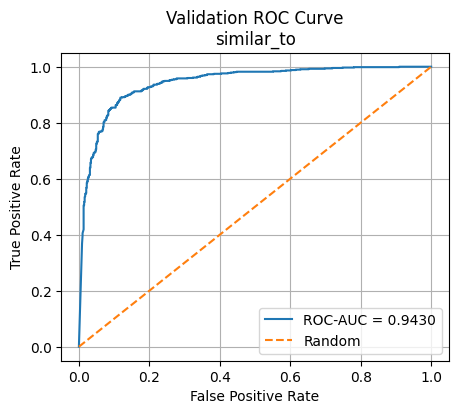

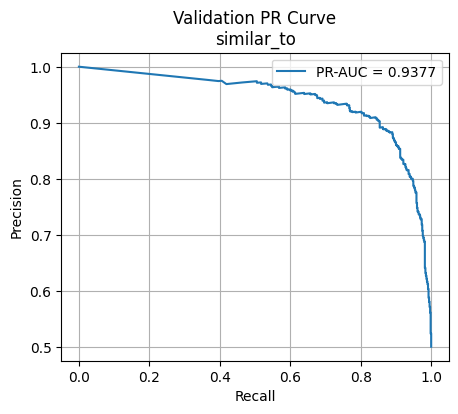

Edge type: ('drug', 'inhibits', 'target')
ROC-AUC : 0.9839
PR-AUC  : 0.9878


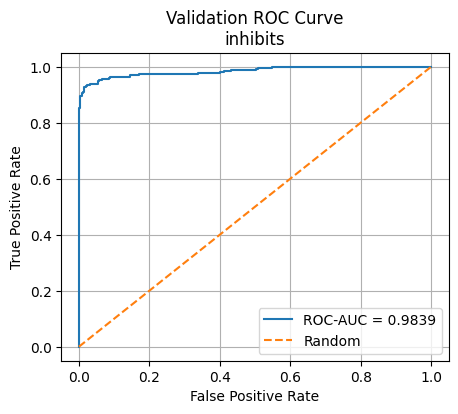

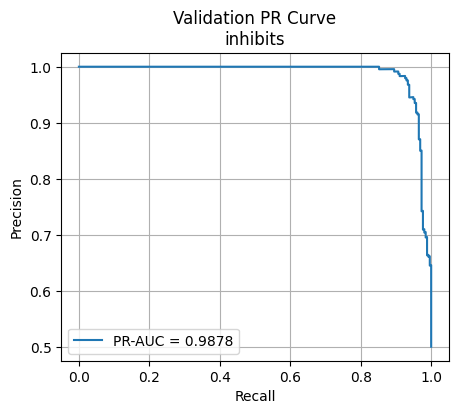

In [100]:
# -----------------------------
# Validation ROC / PR
# -----------------------------

valid_val_edge_types = [
    et for et in TASK_EDGE_TYPES
    if et in val_data.edge_types and hasattr(val_data[et], "edge_label_index")
]

val_pred_results = collect_link_prediction_probs(
    model=model,
    loaders=val_loader,
    edge_types=valid_val_edge_types,
    device=DEVICE,
)

plot_roc_pr_curves(
    pred_results=val_pred_results,
    title_prefix="Validation",
)